In [4]:
# Hidden Markov Models (HMMs) are a powerful tool for analyzing sequential data and identifying
# underlying states within a system. In the context of stock markets, HMMs can be used to detect different
# market regimes or states, providing valuable insights for strategic trading decisions.

In [1]:
import numpy as np
import pandas as pd
from openbb import obb
obb.user.preferences.output_type = "dataframe"
import datetime as dt

In [2]:
# Set parameters for data retrieval
num_years = 10
start_date = dt.datetime.now() - dt.timedelta(days=num_years * 365.25)
end_date = dt.datetime.now()

start_date = start_date.strftime('%Y-%m-%d')
end_date = end_date.strftime('%Y-%m-%d')

In [22]:
#tickers = {"AAPL": "Apple", "MSFT": "Microsoft", "NVDA": "Nvidia", "GOOGL": "Google", "AMZN": "Amazon"}
tickers = {"AAPL": "Apple", "MSFT":"Microsoft"}

symbols = list(tickers.keys())

In [23]:
tickers_data_ = obb.equity.price.historical(
    symbols,
    start_date=start_date,
    end_date=end_date,
    provider="yfinance"
)

In [24]:
data = tickers_data_.pivot( columns='symbol', values='close')
print(data.head())

symbol       AAPL   MSFT
date                    
2014-03-17  18.81  38.05
2014-03-18  18.98  39.55
2014-03-19  18.97  39.27
2014-03-20  18.88  40.33
2014-03-21  19.03  40.16


In [25]:
# Implementing Hidden Markov Models: Building the HMM Model and Training it on the Stock Market Data
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

In [26]:
# Preprocessing Stock Market Data (Example: Normalizing data)
normalized_data = (data - data.mean()) / data.std()

In [27]:
# Initializing and Training the HMM Model with preprocessed data
model = GaussianHMM(n_components=3, covariance_type="full", n_iter=1000)
model.fit(normalized_data)
print("[Training Hidden Markov Model] Training completed.")

[Training Hidden Markov Model] Training completed.


In [28]:
# Predicting Market States using preprocessed data
hidden_states = model.predict(normalized_data)

In [29]:
# Hypothetical Trading Strategy based on identified market states
buy_signal = (hidden_states == 0) # Buy when in Regime 1
sell_signal = (hidden_states == 2) # Sell when in Regime 3

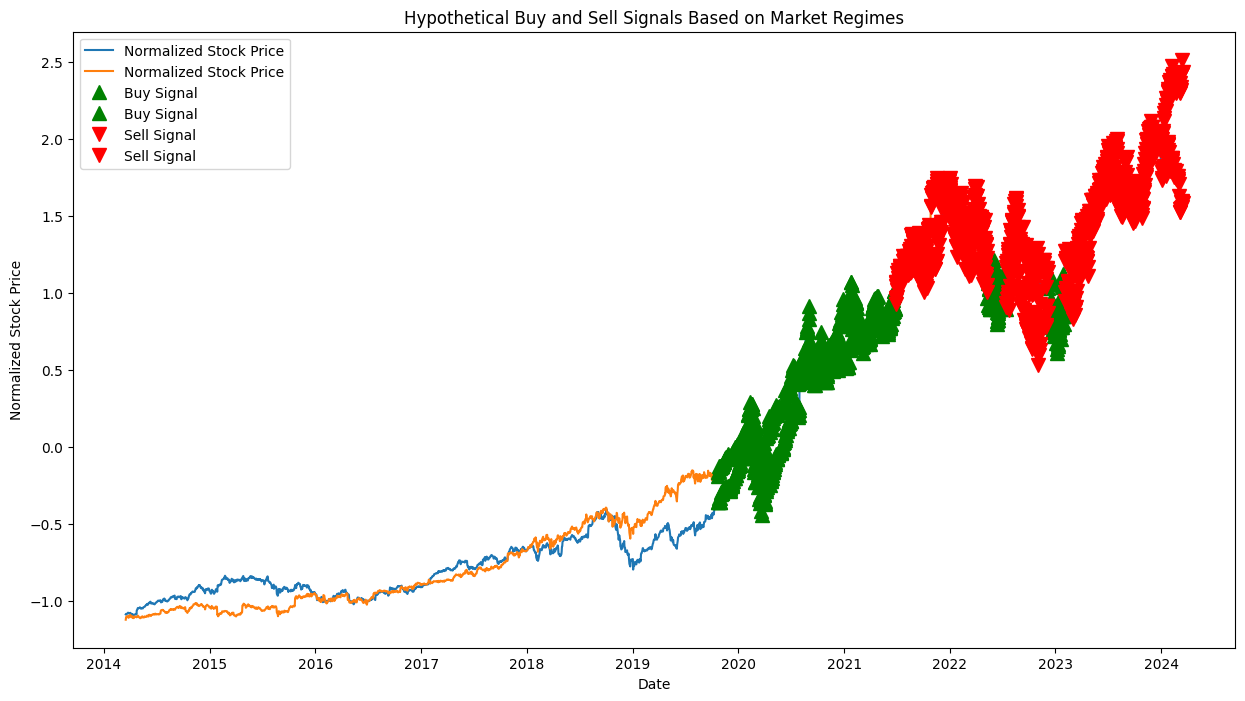

In [30]:
# Visualizing Buy and Sell Signals along with stock price plot
plt.figure(figsize=(15, 8))
plt.plot(data.index, normalized_data, label='Normalized Stock Price')
plt.plot(data.index[buy_signal], normalized_data[buy_signal], '^', markersize=10, color='g', label='Buy Signal')
plt.plot(data.index[sell_signal], normalized_data[sell_signal], 'v', markersize=10, color='r', label='Sell Signal')
plt.title('Hypothetical Buy and Sell Signals Based on Market Regimes')
plt.xlabel('Date')
plt.ylabel('Normalized Stock Price')
plt.legend()